# Exercise 1: Load the EMG data example

In [2]:
import wfdb
import matplotlib.pyplot as plt
import numpy as np

record_name = "emg_healthy"
record = wfdb.rdrecord(record_name, pn_dir="emgdb")
# Extract the signal (first channel)
emg = record.p_signal[:, 0]
fs = record.fs
t = np.arange(len(emg)) / fs


# Exercise 2: Plot the EMG in the time domain.

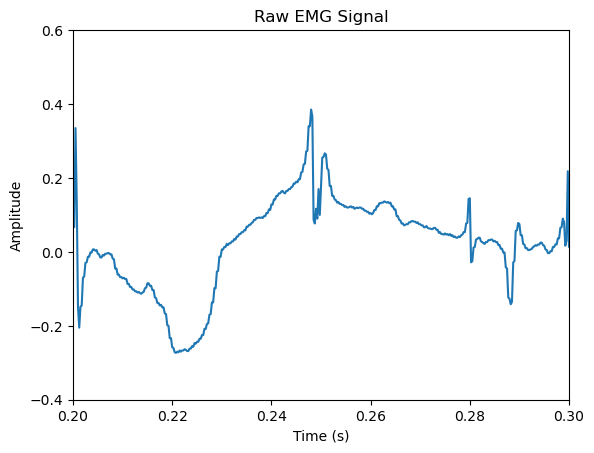

In [3]:
plt.plot(t,emg)
plt.xlim(0.2, 0.3)
plt.ylim(-0.4, 0.6)
plt.title("Raw EMG Signal")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.show()

# Exercise 3: Filter the data.

After creating the filter coeficients from Butter/Notch, we apply it with the filtfilt() from Scipty: https://docs.scipy.org/doc/scipy-1.16.1/reference/generated/scipy.signal.filtfilt.html

This function applies a linear digital filter twice, once forward and once backwards. The combined filter has zero phase and a filter order twice that of the original.

### Butterworth
See: https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.butter.html

In [4]:
from scipy.signal import butter, filtfilt
order = 4
fcut_low = 20
fcut_high = 450
nyquist = fs / 2

#Calculate coefficients for the filter (For Wn we need to normalize, which we do with the Nyquist frequency)
b_butter, a_butter = butter(N = order, Wn = [fcut_low/nyquist, fcut_high/nyquist], btype='bandpass')
emg_butter = filtfilt(b_butter, a_butter, emg)


### Notch filter
See: https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.iirnotch.html

w0: Frequency to remove from a signal. If fs is specified, this is in the same units as fs. By default, it is a normalized scalar that must satisfy 0 < w0 < 1, with w0 = 1 corresponding to half of the sampling frequency.

Q: Quality factor. Dimensionless parameter that characterizes notch filter -3 dB bandwidth bw relative to its center frequency, Q = w0/bw.



In [5]:
from scipy.signal import iirnotch

w0 = 50
Q = 30

b_notch, a_notch = iirnotch(w0 = w0, Q = Q, fs = fs)

emg_filtered = filtfilt(b_notch, a_notch, emg_butter)

We can see the effect of the filtering by plotting the Raw and filtered data in the frequency domain.

See: https://www.geeksforgeeks.org/numpy/numpy-for-fast-fourier-transform-fft-analysis/

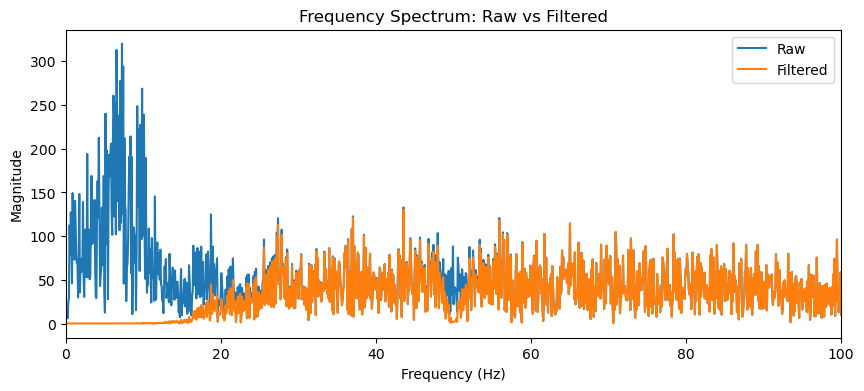

In [6]:
# frequency axis
N = len(emg_filtered)
T = 1/fs
freqs = np.fft.fftfreq(N, T)

# Raw signal
fft_vals_raw = np.fft.fft(emg)
magnitude_raw = np.abs(fft_vals_raw)

# Filtered signal
fft_filtered = np.fft.fft(emg_filtered)
magnitude_filtered = np.abs(fft_filtered)

#Plotting
plt.figure(figsize=(10,4))
plt.plot(freqs[:N//2], magnitude_raw[:N//2], label="Raw")
plt.plot(freqs[:N//2], magnitude_filtered[:N//2], label="Filtered")
plt.xlim(0,100)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.title("Frequency Spectrum: Raw vs Filtered")
plt.legend()
plt.show()

When zoomin in a bit, we can see that the Butterworth filter has removed frequencies below 20Hz (also above 450 not shown here).

We also observe that the Notch filter has removed frequencies at 50Hz.

# Exercise 4: Segment the filtered EMG into fixed windows

We achieve this with a simple for loop.

In [7]:
window_duration = 0.2 #seconds
overlap = 0.5 #fraction overlap
window_size = int(window_duration * fs)
step_size = int(window_size*overlap)

segments = []

for start in range(0, len(emg), step_size):
    segment = emg[start:start+window_size]
    segments.append(segment)

Plot some of the segments to check if looks correct.

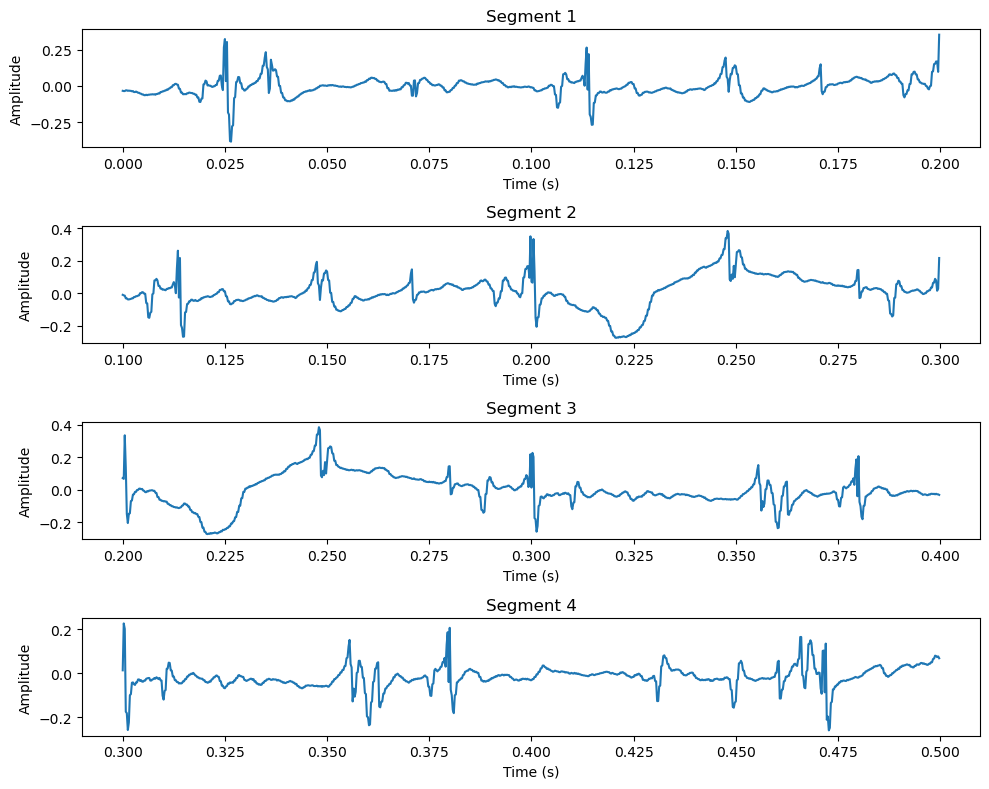

In [8]:
plt.figure(figsize=(10,8))
for i in range(4):
    step = i * step_size
    plt.subplot(4, 1, i+1)
    plt.plot(t[step:step+800],segments[i])
    plt.title(f"Segment {i+1}")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")

plt.tight_layout()
plt.show()

The segmentation of the first 4 segments looks correct. All are of length 200 ms and they overlap 50%.

# Exercise 5: Compute classic time-domain features

For reference see: https://github.com/Jovinus/RoboticHand-EMG

### MAV (Mean Absolute Value)

$$
MAV = \frac{1}{N}\sum_{i=1}^{N} |x_i|
$$

In [9]:
def MAV(x):
    sum = 0
    for value in x:
        sum += np.absolute(value)
    return sum/len(x)

print(MAV(emg_filtered))

0.03416612776028632


### RMS (Root-Mean-Square)
$$
RMS = \sqrt{\frac{1}{N}\sum_{i=1}^{N} x_i^2}
$$

In [10]:
def RMS(x):
    sum = 0
    for value in x:
        sum += np.square(value)
    return np.sqrt(sum/len(x))

print(RMS(emg_filtered))

0.0597219415397245


### WL (Waveform Length)
Cumulative length of the waveform over time.
$$
WL = \sum_{i=1}^{N-1} |x_{i+1} - x_i|
$$

In [11]:
def WL(x):
    sum = 0
    for i in range(len(x)-1):
        sum += np.absolute(x[i+1]-x[i])
    return sum

print(WL(emg_filtered))

405.41368228359704


### ZC (Zero Crossings)
Number of times the EMG changes from positive to negative or vice versa (with a minimum threshold, T).
$$
ZC = \sum_{i=1}^{N-1}
\begin{cases}
1, & \text{if } x_i \cdot x_{i+1} < 0 \ \text{and } |x_i - x_{i+1}| > T \\
0, & \text{otherwise}
\end{cases}
$$

In [12]:
def ZC(x, T = 0.01):
    sum = 0
    for i in range(len(x)-1):
          #Must be negative   Change must be larger than set Threshold, T
        if x[i]*x[i+1] < 0 and np.absolute(x[i]-x[i+1]) > T:
            sum += 1
    return sum

T = 0.01 # Found by investigating emg_filtered vs time plot
print(ZC(emg_filtered, T))

1195


### SSC (Slope Sign Changes)
Number of times the slope of the EMG changes from positive to negative or vice versa (with a minimum threshold, T).
$$
SSC = \sum_{i=2}^{N-1}
\begin{cases}
1, & \text{if } (x_i - x_{i-1})(x_i - x_{i+1}) \text{ and } (x_i - x_{i-1}) > T \text{ and } (x_i - x_{i+1}) > T\\
0, & \text{otherwise}
\end{cases}
$$

In [13]:
def SSC(x, T = 0.01):
    sum = 0
    for i in range(1,len(x)-1):
        diff1 = x[i]-x[i-1]
        diff2 = x[i]-x[i+1]
        # The Product of diff1 and diff2 must be positive for a slope change
        if diff1 * diff2 and (abs(diff1) > T and abs(diff2) > T):
            sum += 1
    return sum

print(SSC(emg_filtered, T))

8402


# Exercise 6: k-means clustering

### Extract features from all window segments

In [14]:
features = []

for segment in segments:
    f = [
        MAV(segment),
        RMS(segment),
        WL(segment),
        ZC(segment),
        SSC(segment)
    ]
    features.append(f)

features = np.array(features)

### Perform K-means clustering for 3 cluster

KMeans: https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html

The KMeans algorithm clusters data by trying to separate samples in n groups of equal variance, minimizing a criterion known as the inertia or within-cluster sum-of-squares (see below). This algorithm requires the number of clusters to be specified. It scales well to large numbers of samples and has been used across a large range of application areas in many different fields.

For further description of the algorithm see: https://scikit-learn.org/stable/modules/clustering.html#k-means

StandardScaler: https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html

Standardize features by removing the mean and scaling to unit variance.

In [15]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Standardize features
scaler = StandardScaler()
Xz = scaler.fit_transform(features)

# K-Means clustering
k = 3
kmeans = KMeans(n_clusters=k, n_init=20, random_state=0)
labels = kmeans.fit_predict(Xz)
centroids_std = kmeans.cluster_centers_
centroids = scaler.inverse_transform(centroids_std)

# Print centroids
feat_names = ["MAV", "RMS", "WL", "ZC", "SSC"]
print("\nCluster centroids:")
for idx, c in enumerate(centroids):
    print(f"  Cluster {idx +1}: " + ", ".join(f"{n} = {v:.4f}" for n, v in zip(feat_names, c)))


Cluster centroids:
  Cluster 1: MAV = 0.0447, RMS = 0.0646, WL = 9.3658, ZC = 26.5053, SSC = 32.4421
  Cluster 2: MAV = 0.0825, RMS = 0.1139, WL = 11.3501, ZC = 20.9688, SSC = 37.7500
  Cluster 3: MAV = 0.0100, RMS = 0.0119, WL = 0.1296, ZC = 0.0000, SSC = 0.0000


C:\Users\Niels\anaconda3\envs\PDP\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


### Plot clusters pairwise

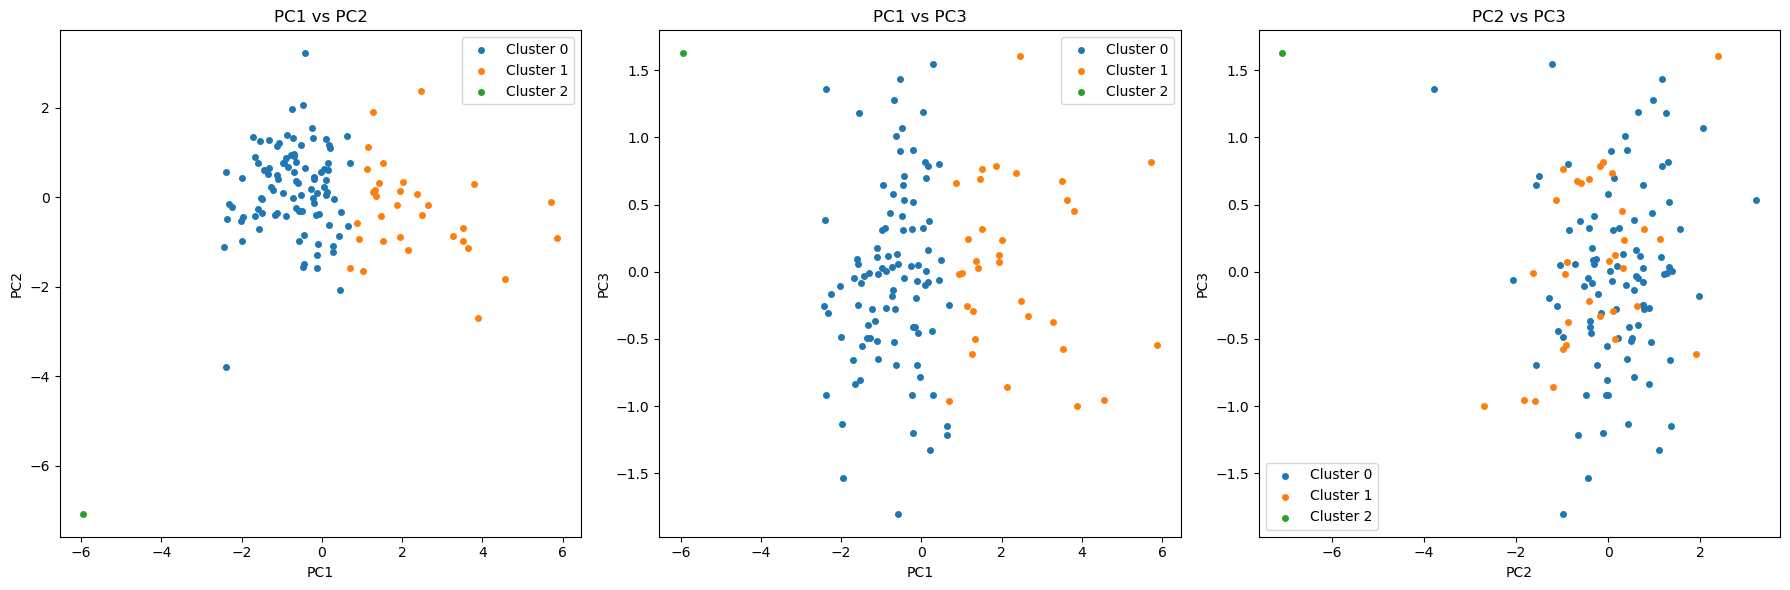

In [49]:
from sklearn.decomposition import PCA
from itertools import combinations # Generates unique combinations for example: combinations([0, 1, 2], 2) → (0,1), (0,2), (1,2)

Z = PCA(n_components=3, random_state=0).fit_transform(Xz)
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes = axes.flatten()

uniques = np.unique(labels)
pairs = list(combinations(range(len(uniques)), 2))

for k, (i, j) in enumerate(pairs):
    for lab in np.unique(labels):
        idx = labels == lab
        axes[k].scatter(Z[idx, i], Z[idx, j], s=16, label=f"Cluster {lab}")
        axes[k].set_title(f"PC{i+1} vs PC{j+1}")
        axes[k].set_xlabel(f"PC{i+1}")
        axes[k].set_ylabel(f"PC{j+1}")
        axes[k].legend()

plt.tight_layout()

plt.show()

We notice that one of the clusters (cluster 2) consists of a single datapoint, which might be an outlier.

### Plot feature maps
We wanted to see the clustering across all the features, so we plotted the feature maps.

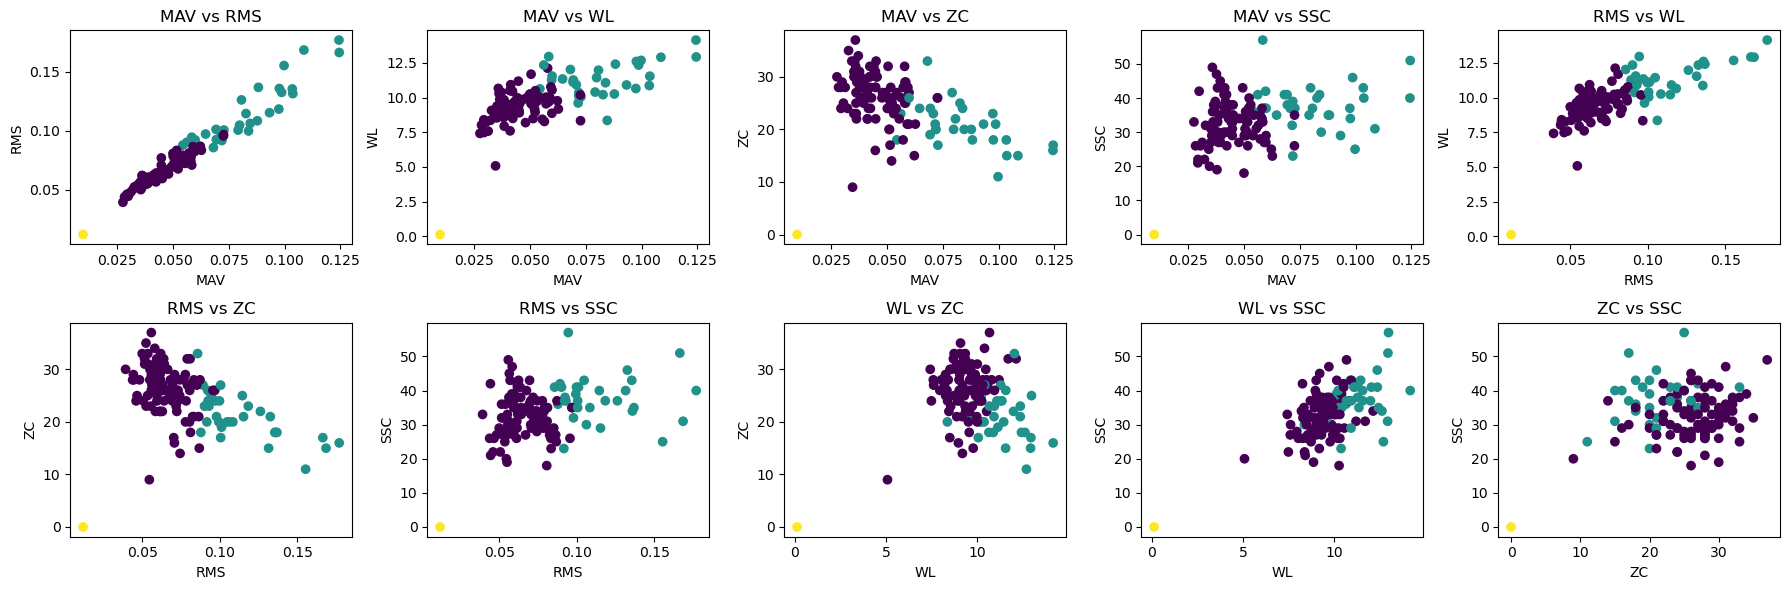

In [72]:
pairs = list(combinations(range(len(feat_names)), 2))

fig, axes = plt.subplots(2, 5, figsize=(18, 6))
axes = axes.flatten()

for k, (i, j) in enumerate(pairs):
    axes[k].scatter(features[:, i], features[:, j], c=labels)
    axes[k].set_title(f"{feat_names[i]} vs {feat_names[j]}")
    axes[k].set_xlabel(feat_names[i])
    axes[k].set_ylabel(feat_names[j])

plt.tight_layout()
plt.show()

For fun we asked Chat GPT to make an interactive 3-D plot of the three principal components of the K-means.

In [51]:
from sklearn.decomposition import PCA
import plotly.express as px
import pandas as pd

# PCA to 3 components
pca = PCA(n_components=3)
X_pca = pca.fit_transform(Xz)

# Transform centroids to PCA space
centroids_pca = pca.transform(centroids_std)

# Create dataframe for plotting
df_plot = pd.DataFrame({
    "PC1": X_pca[:,0],
    "PC2": X_pca[:,1],
    "PC3": X_pca[:,2],
    "Cluster": labels.astype(str)
})

# Plot points
fig = px.scatter_3d(
    df_plot,
    x="PC1",
    y="PC2",
    z="PC3",
    color="Cluster",
    title="Interactive 3D PCA Projection of K-Means Clusters"
)

# Add centroids
fig.add_scatter3d(
    x=centroids_pca[:,0],
    y=centroids_pca[:,1],
    z=centroids_pca[:,2],
    mode="markers",
    marker=dict(size=5, symbol="diamond"),
    name="Centroids"
)

fig.show()

For a better view we can open this in a browser.

In [1]:
import plotly.io as pio

# Open interactive plot in browser
pio.show(fig, renderer="browser")

NameError: name 'fig' is not defined